# Benemérita Universidad Autónoma de Puebla (BUAP)
## Facultad de Ciencias de la Computación | Licenciatura en Ingeniería en Ciencia de Datos
### Asignatura: Estadística para Ciencia de Datos (ICDA 250)
---
# Proyecto Integrador de la Unidad 1: Análisis Exploratorio de Datos (EDA)
## Estudio Epidemiológico de Factores de Riesgo en Accidentes Cerebrovasculares (ACV / Stroke)
### GUÍA DE TRABAJO PRÁCTICO - ESTUDIANTE
### Angel Uriel Lopez Vazquez

---

### Contexto del Problema:
Un accidente cerebrovascular (ACV o *stroke*) ocurre cuando se detiene o reduce el flujo de sangre a una parte del cerebro, impidiendo que el tejido cerebral reciba oxígeno y nutrientes. De acuerdo con la Organización Mundial de la Salud (OMS), es la segunda causa de muerte a nivel mundial.

En este proyecto integrador asumirás el rol de **Científico de Datos en Salud Pública**. Trabajarás con un conjunto de datos clínicos reales de **5,110 pacientes**, que incluye mediciones biomédicas (glucosa promedio, índice de masa corporal), antecedentes médicos (hipertensión, cardiopatías), variables sociodemográficas (edad, estado civil, tipo de empleo, residencia) y hábitos de vida (tabaquismo).

### Objetivo del Proyecto:
Aplicar de manera integral todos los conceptos, métodos estadísticos y técnicas de programación en Python abordados en la **Unidad 1**:
1. Identificación y clasificación formal de escalas de medición.
2. Auditoría de calidad de datos y tratamiento fundamentado de valores faltantes (`NaN`).
3. Limpieza de inconsistencias y codificación de variables categóricas (One-Hot / Binaria).
4. Cálculo e interpretación comparativa de estadísticas descriptivas clásicas vs. medidas robustas.
5. Detección y cuantificación de valores atípicos mediante el criterio de Tukey (IQR).
6. Diagnóstico analítico y visual de normalidad (Asimetría, Curtosis, Q-Q Plot, Shapiro-Wilk, D'Agostino-Pearson).
7. Transformación de variables continuas asimétricas mediante la transformación de Yeo-Johnson.
8. Análisis de correlación lineal y no paramétrica (Spearman) para identificar factores de riesgo asociados al ACV.
9. Construcción de un pipeline modular y reproducible de preprocesamiento estadístico.
10. Elaboración de un panel de visualización clínica (*Healthcare Analytics Dashboard*).

---
### Dinámica de Evaluación y Autoverificación:
- Cada inciso contiene una descripción técnica precisa y una celda de código con la plantilla `# TODO:`.
- Debajo de cada ejercicio encontrarás una celda de **`# --- VERIFICACIÓN / PRUEBA UNITARIA ---`** que utiliza aserciones (`assert`).
- Al ejecutar tu código y superar la prueba unitaria, la celda imprimirá un mensaje confirmando que tu respuesta cumple con los criterios estadísticos requeridos.


## 1. Configuración del Entorno y Carga de Datos

Comenzamos importando las librerías esenciales del ecosistema científico de Python (`pandas`, `numpy`, `scipy.stats`, `matplotlib.pyplot`, `seaborn`) y configurando un estilo visual moderno para las representaciones gráficas.


In [30]:
import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

print("Entorno estadístico configurado correctamente.")
print(f"NumPy: {np.__version__} | Pandas: {pd.__version__} | SciPy: {scipy.__version__}")


Entorno estadístico configurado correctamente.
NumPy: 1.26.4 | Pandas: 2.2.2 | SciPy: 1.14.1


## 2. Inciso 1: Identificación y Clasificación de Escalas de Medición

En el flujo de trabajo de la Ciencia de Datos, antes de aplicar cualquier fórmula o gráfico es imprescindible reconocer la **escala de medición** de cada variable:
- **Cualitativa Nominal**: Categorías mutuamente excluyentes sin orden natural (e.g. género, tipo de residencia).
- **Cualitativa Ordinal**: Categorías con un orden o jerarquía intrínseca.
- **Cuantitativa Discreta**: Valores numéricos contables enteros (e.g. presencia/ausencia binaria 0/1, conteos).
- **Cuantitativa Continua**: Valores numéricos medibles en una escala continua con decimales (e.g. edad, nivel de glucosa, IMC).

### Instrucciones:
Implementa la función `clasificar_escalas(df: pd.DataFrame) -> dict` que reciba el DataFrame y devuelva un diccionario donde las claves sean los nombres de las 11 variables analíticas (excluyendo la columna identificadora `'id'`) y los valores sean exactamente una de las siguientes cuatro cadenas:
`'Cualitativa Nominal'`, `'Cualitativa Ordinal'`, `'Cuantitativa Discreta'` o `'Cuantitativa Continua'`.

*Nota:* Las variables binarias de condición médica (`hypertension`, `heart_disease`, `stroke`) se clasifican como `'Cuantitativa Discreta'` (indicatrices binarias 0/1).


In [31]:
def clasificar_escalas(df: pd.DataFrame) -> dict:
    return {
        'gender': 'Cualitativa Nominal',
        'age': 'Cuantitativa Continua',
        'hypertension': 'Cuantitativa Discreta',
        'heart_disease': 'Cuantitativa Discreta',
        'ever_married': 'Cualitativa Nominal',
        'work_type': 'Cualitativa Nominal',
        'Residence_type': 'Cualitativa Nominal',
        'avg_glucose_level': 'Cuantitativa Continua',
        'bmi': 'Cuantitativa Continua',
        'smoking_status': 'Cualitativa Nominal',
        'stroke': 'Cuantitativa Discreta'
    }

try:
    df_raw = pd.read_csv("healthcare_stroke_data.csv")
    escalas = clasificar_escalas(df_raw)
    assert isinstance(escalas, dict), "La salida debe ser un diccionario"
    assert len(escalas) == 11, f"Se esperaban 11 variables analizadas, pero se recibieron {len(escalas)}"
    assert escalas["gender"] == "Cualitativa Nominal"
    assert escalas["age"] == "Cuantitativa Continua"
    assert escalas["avg_glucose_level"] == "Cuantitativa Continua"
    assert escalas["bmi"] == "Cuantitativa Continua"
    assert escalas["stroke"] == "Cuantitativa Discreta"
    assert escalas["hypertension"] == "Cuantitativa Discreta"
    assert escalas["work_type"] == "Cualitativa Nominal"
    print("¡Inciso 1 verificado con éxito! Las escalas de medición han sido clasificadas con rigor estadístico.")
except Exception as e:
    print(f"Error en Inciso 1: {type(e).__name__} -> {e}")


¡Inciso 1 verificado con éxito! Las escalas de medición han sido clasificadas con rigor estadístico.


## 3. Inciso 2: Auditoría de Calidad y Cuantificación de Valores Faltantes

Un paso crítico en cualquier análisis exploratorio es cuantificar el impacto de los valores faltantes antes de decidir su tratamiento (eliminación de filas vs imputación).

### Instrucciones:
Implementa la función `analizar_nulos(df: pd.DataFrame) -> pd.DataFrame` que calcule para cada columna del DataFrame:
1. El número total de valores nulos (`"nulos_totales"`).
2. El porcentaje que representan respecto al total de filas (`"porcentaje_nulos"`), redondeado a 2 decimales.
3. El DataFrame resultante debe tener como índice los nombres de las columnas y estar ordenado descendentemente por `"nulos_totales"`.


In [32]:
def analizar_nulos(df: pd.DataFrame) -> pd.DataFrame:
    nulos_totales = df.isna().sum()
    porcentaje_nulos = (nulos_totales / len(df) * 100).round(2)
    resumen = pd.DataFrame({
        'nulos_totales': nulos_totales,
        'porcentaje_nulos': porcentaje_nulos
    })
    return resumen.sort_values('nulos_totales', ascending=False)

try:
    df_raw = pd.read_csv("healthcare_stroke_data.csv")
    resumen_nulos = analizar_nulos(df_raw)
    assert isinstance(resumen_nulos, pd.DataFrame), "El resultado debe ser un DataFrame"
    assert "nulos_totales" in resumen_nulos.columns and "porcentaje_nulos" in resumen_nulos.columns
    # bmi es la única columna con nulos en este dataset
    assert resumen_nulos.loc["bmi", "nulos_totales"] == 201, f"bmi debe tener 201 nulos, se obtuvo: {resumen_nulos.loc['bmi', 'nulos_totales']}"
    assert np.isclose(resumen_nulos.loc["bmi", "porcentaje_nulos"], 3.93, atol=0.05), "El porcentaje de nulos en bmi debe ser ~3.93%"
    print("¡Inciso 2 verificado con éxito! Auditoría de valores faltantes completada:")
    print(resumen_nulos[resumen_nulos["nulos_totales"] > 0])
except Exception as e:
    print(f"Error en Inciso 2: {type(e).__name__} -> {e}")


¡Inciso 2 verificado con éxito! Auditoría de valores faltantes completada:
     nulos_totales  porcentaje_nulos
bmi            201              3.93


## 4. Inciso 3: Imputación Robusta del Índice de Masa Corporal (`bmi`)

El Índice de Masa Corporal (`bmi`) presenta valores faltantes en 201 pacientes. Debido a que el IMC contiene valores atípicos elevados (pacientes con obesidad mórbida con IMC > 60), imputar con la **media aritmética** distorsionaría la distribución central. Por tanto, la **mediana** es la medida robusta recomendada.

### Instrucciones:
Implementa la función `imputar_bmi_mediana(df: pd.DataFrame) -> pd.DataFrame` que:
1. Cree una copia independiente del DataFrame (`df.copy()`).
2. Calcule la mediana de la columna `'bmi'` ignorando nulos.
3. Rellene los valores faltantes en `'bmi'` con dicha mediana.
4. Retorne el DataFrame modificado asegurando que no queden valores nulos en `'bmi'`.


In [33]:
def imputar_bmi_mediana(df: pd.DataFrame) -> pd.DataFrame:
    df_clean = df.copy()
    mediana_bmi = df_clean['bmi'].median()
    df_clean['bmi'] = df_clean['bmi'].fillna(mediana_bmi)
    return df_clean

try:
    df_raw = pd.read_csv("healthcare_stroke_data.csv")
    df_imputado = imputar_bmi_mediana(df_raw)
    assert isinstance(df_imputado, pd.DataFrame), "El resultado debe ser un DataFrame"
    assert df_imputado["bmi"].isna().sum() == 0, "No deben quedar valores nulos en 'bmi'"
    # La mediana debe permanecer invariante tras la imputación
    assert np.isclose(df_imputado["bmi"].median(), df_raw["bmi"].median(), atol=1e-3), "La mediana de bmi no debe cambiar tras la imputación por mediana"
    assert np.isclose(df_imputado["bmi"].median(), 28.1, atol=0.1), "La mediana esperada de bmi es 28.1"
    print("¡Inciso 3 verificado con éxito! Imputación robusta completada (Mediana = 28.1).")
except Exception as e:
    print(f"Error en Inciso 3: {type(e).__name__} -> {e}")


¡Inciso 3 verificado con éxito! Imputación robusta completada (Mediana = 28.1).


## 5. Inciso 4: Depuración de Inconsistencias y Codificación Binaria

En la columna `'gender'` existe exactamente un registro anómalo con valor `'Other'`. En estudios biológicos y epidemiológicos con muestras binarias, los registros únicos sin masa estadística deben filtrarse para evitar distorsiones.

Posteriormente, las variables cualitativas nominales binarias deben codificarse numéricamente:
- `'gender'`: `'Male'` $\to 1$, `'Female'` $\to 0$
- `'ever_married'`: `'Yes'` $\to 1$, `'No'` $\to 0$
- `'Residence_type'`: `'Urban'` $\to 1$, `'Rural'` $\to 0$

### Instrucciones:
Implementa la función `limpiar_y_codificar_binarias(df: pd.DataFrame) -> pd.DataFrame` que:
1. Filtre las filas eliminando aquellas donde `gender == 'Other'`.
2. Mapee las tres columnas a valores enteros $0$ y $1$ según la convención descrita.
3. Retorne el DataFrame procesado.


In [34]:
def limpiar_y_codificar_binarias(df: pd.DataFrame) -> pd.DataFrame:
    df_proc = df[df['gender'] != 'Other'].copy()
    
    df_proc['gender'] = df_proc['gender'].map({'Male': 1, 'Female': 0})
    df_proc['ever_married'] = df_proc['ever_married'].map({'Yes': 1, 'No': 0})
    df_proc['Residence_type'] = df_proc['Residence_type'].map({'Urban': 1, 'Rural': 0})
    
    return df_proc.reset_index(drop=True)

try:
    df_raw = pd.read_csv("healthcare_stroke_data.csv")
    df_cod = limpiar_y_codificar_binarias(df_raw)
    assert len(df_cod) == 5109, f"Se esperaban 5,109 filas tras eliminar 'Other', pero se obtuvieron {len(df_cod)}"
    assert set(df_cod["gender"].unique()) == {0, 1}, "gender debe contener únicamente los valores {0, 1}"
    assert set(df_cod["ever_married"].unique()) == {0, 1}, "ever_married debe contener únicamente los valores {0, 1}"
    assert set(df_cod["Residence_type"].unique()) == {0, 1}, "Residence_type debe contener únicamente los valores {0, 1}"
    assert df_cod["gender"].sum() == 2115, "El total de hombres (Male=1) debe ser 2,115"
    print("¡Inciso 4 verificado con éxito! Depuración y codificación binaria completadas:")
    print(df_cod[["gender", "ever_married", "Residence_type"]].head())
except Exception as e:
    print(f"Error en Inciso 4: {type(e).__name__} -> {e}")


¡Inciso 4 verificado con éxito! Depuración y codificación binaria completadas:
   gender  ever_married  Residence_type
0       1             1               1
1       0             1               0
2       1             1               0
3       0             1               1
4       0             1               0


## 6. Inciso 5: Comparativa de Estadísticas Descriptivas Clásicas vs Robustas

La variable `'avg_glucose_level'` (Nivel promedio de glucosa en sangre en mg/dL) presenta pacientes con hiperglucemia extrema (> 250 mg/dL).
Para evaluar cuantitativamente el sesgo de las medidas clásicas, compararemos:
- **Tendencia Central**:
  - Media aritmética convencional: $\bar{x} = \frac{1}{n} \sum x_i$ (sensible a valores extremos).
  - Mediana: Percentil 50 (50% de resistencia ante outliers).
  - Media recortada al 5% (*Trimmed Mean*): Se descarta el 5% superior y el 5% inferior (`scipy.stats.trim_mean(datos, proportiontocut=0.05)`).
- **Dispersión**:
  - Desviación estándar ($s$, con $n-1$).
  - Rango Intercuartílico ($IQR = Q_3 - Q_1$).
  - Desviación Absoluta de la Mediana ($MAD = \text{mediana}(|x_i - \text{mediana}(x)|)$).

### Instrucciones:
Implementa la función `estadisticas_robustas(serie: pd.Series) -> dict` que reciba una serie numérica y retorne un diccionario con las 6 métricas redondeadas a 2 decimales:
`{"media": float, "mediana": float, "media_recortada_5pct": float, "desv_estandar": float, "iqr": float, "mad": float}`.


In [35]:
def estadisticas_robustas(serie: pd.Series) -> dict:
    datos = serie.dropna()
    
    media = datos.mean()
    mediana = datos.median()
    media_recortada = stats.trim_mean(datos, proportiontocut=0.05)
    desv_estandar = datos.std(ddof=1)
    iqr = datos.quantile(0.75) - datos.quantile(0.25)
    mad = np.median(np.abs(datos - datos.median()))
    
    return {
        'media': round(media, 2),
        'mediana': round(mediana, 2),
        'media_recortada_5pct': round(media_recortada, 2),
        'desv_estandar': round(desv_estandar, 2),
        'iqr': round(iqr, 2),
        'mad': round(mad, 2)
    }

try:
    df_raw = pd.read_csv("healthcare_stroke_data.csv")
    metrics_glucosa = estadisticas_robustas(df_raw["avg_glucose_level"])
    assert isinstance(metrics_glucosa, dict), "El resultado debe ser un diccionario"
    assert "media" in metrics_glucosa and "mediana" in metrics_glucosa and "mad" in metrics_glucosa
    assert np.isclose(metrics_glucosa["media"], 106.15, atol=0.2), f"Media esperada ~106.15, obtenida: {metrics_glucosa['media']}"
    assert np.isclose(metrics_glucosa["mediana"], 91.88, atol=0.2), f"Mediana esperada ~91.88, obtenida: {metrics_glucosa['mediana']}"
    assert metrics_glucosa["media"] > metrics_glucosa["mediana"], "La media debe ser mayor que la mediana debido al sesgo positivo a la derecha"
    assert np.isclose(metrics_glucosa["iqr"], 36.84, atol=0.2), f"IQR esperado ~36.84, obtenido: {metrics_glucosa['iqr']}"
    print("¡Inciso 5 verificado con éxito! Métricas descriptivas calculadas:")
    for k, v in metrics_glucosa.items():
        print(f" - {k}: {v}")
except Exception as e:
    print(f"Error en Inciso 5: {type(e).__name__} -> {e}")


¡Inciso 5 verificado con éxito! Métricas descriptivas calculadas:
 - media: 106.15
 - mediana: 91.88
 - media_recortada_5pct: 101.86
 - desv_estandar: 45.28
 - iqr: 36.84
 - mad: 17.58


## 7. Inciso 6: Detección y Cuantificación de Outliers (Criterio de Tukey / IQR)

El criterio de John Tukey define las barreras de valores atípicos a partir de los cuartiles:
$$\text{Límite Inferior} = Q_1 - 1.5 \times IQR$$
$$\text{Límite Superior} = Q_3 + 1.5 \times IQR$$

Los valores fuera de este intervalo se consideran atípicos. En medicina, los niveles altos de glucosa corresponden a crisis hiperglucémicas o diabetes descompensada.

### Instrucciones:
Implementa la función `detectar_outliers_tukey(df: pd.DataFrame, columna: str) -> dict` que calcule:
- `q1`: Primer cuartil (0.25).
- `q3`: Tercer cuartil (0.75).
- `iqr`: Rango intercuartílico ($Q_3 - Q_1$).
- `limite_inferior`: $Q_1 - 1.5 \times IQR$.
- `limite_superior`: $Q_3 + 1.5 \times IQR$.
- `total_outliers`: Conteo de observaciones por debajo del límite inferior o por encima del límite superior.
- `porcentaje_outliers`: Porcentaje de filas outliers respecto al total analizado, redondeado a 2 decimales.


In [36]:
def detectar_outliers_tukey(df: pd.DataFrame, columna: str) -> dict:
    datos = df[columna].dropna()
    
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    total_outliers = ((datos < limite_inferior) | (datos > limite_superior)).sum()
    porcentaje_outliers = total_outliers / len(datos) * 100
    
    return {
        'q1': round(q1, 2),
        'q3': round(q3, 2),
        'iqr': round(iqr, 2),
        'limite_inferior': round(limite_inferior, 2),
        'limite_superior': round(limite_superior, 2),
        'total_outliers': int(total_outliers),
        'porcentaje_outliers': round(porcentaje_outliers, 2)
    }

try:
    df_raw = pd.read_csv("healthcare_stroke_data.csv")
    outliers_glucosa = detectar_outliers_tukey(df_raw, "avg_glucose_level")
    assert isinstance(outliers_glucosa, dict), "El resultado debe ser un diccionario"
    assert np.isclose(outliers_glucosa["q1"], 77.25, atol=0.2), "Q1 incorrecto"
    assert np.isclose(outliers_glucosa["q3"], 114.09, atol=0.2), "Q3 incorrecto"
    assert np.isclose(outliers_glucosa["limite_superior"], 169.36, atol=0.5), "Límite superior incorrecto"
    assert outliers_glucosa["total_outliers"] == 627, f"Se esperaban 627 outliers en glucosa, obtenidos: {outliers_glucosa['total_outliers']}"
    assert np.isclose(outliers_glucosa["porcentaje_outliers"], 12.27, atol=0.1), "Porcentaje de outliers esperado: ~12.27%"
    print("¡Inciso 6 verificado con éxito! Detección de Tukey superada:")
    for k, v in outliers_glucosa.items():
        print(f" - {k}: {v}")
except Exception as e:
    print(f"Error en Inciso 6: {type(e).__name__} -> {e}")


¡Inciso 6 verificado con éxito! Detección de Tukey superada:
 - q1: 77.24
 - q3: 114.09
 - iqr: 36.84
 - limite_inferior: 21.98
 - limite_superior: 169.36
 - total_outliers: 627
 - porcentaje_outliers: 12.27


## 8. Inciso 7: Diagnóstico Estadístico y Visual de Normalidad

Para determinar formalmente si la glucosa sigue una distribución Gaussiana, evaluamos su forma y ejecutamos pruebas de hipótesis:
- **Asimetría (Skewness)**: Medida de simetría (una normal teórica tiene skewness $= 0$). Valores $> 1$ indican asimetría positiva sustancial con cola larga a la derecha.
- **Curtosis de Fisher**: Mide el grosor de las colas (una normal teórica tiene curtosis $= 0$).
- **Prueba de D'Agostino-Pearson (`stats.normaltest`)**: Prueba omnibus basada en asimetría y curtosis para grandes muestras ($N > 5000$).
  - $H_0$: Los datos provienen de una población normal.
  - $H_1$: Los datos no provienen de una distribución normal.
  - Regla: Rechazar $H_0$ si $p\text{-valor} < 0.05$.

### Instrucciones:
Implementa la función `diagnostico_forma_normalidad(datos: np.ndarray) -> dict` que calcule:
- `asimetria`: float con `stats.skew(datos)`.
- `curtosis`: float con `stats.kurtosis(datos)`.
- `estadistico_dagostino`: float con el estadístico de `stats.normaltest(datos)`.
- `p_valor_dagostino`: float con el p-valor de `stats.normaltest(datos)`.
- `es_normal`: booleano (`True` si $p \ge 0.05$, `False` si $p < 0.05$).


In [37]:
def diagnostico_forma_normalidad(datos: np.ndarray) -> dict:
    datos = datos[~np.isnan(datos)]
    
    asimetria = stats.skew(datos)
    curtosis = stats.kurtosis(datos)
    estadistico, p_valor = stats.normaltest(datos)
    es_normal = bool(p_valor >= 0.05)
    
    return {
        'asimetria': round(asimetria, 4),
        'curtosis': round(curtosis, 4),
        'estadistico_dagostino': round(estadistico, 4),
        'p_valor_dagostino': p_valor,
        'es_normal': es_normal
    }

try:
    df_raw = pd.read_csv("healthcare_stroke_data.csv")
    diag_glucosa = diagnostico_forma_normalidad(df_raw["avg_glucose_level"].values)
    assert isinstance(diag_glucosa, dict), "El resultado debe ser un diccionario"
    assert abs(diag_glucosa["asimetria"] - 1.57) < 0.1, f"Asimetría esperada ~1.57, obtenida: {diag_glucosa['asimetria']}"
    assert diag_glucosa["asimetria"] > 1.0, "La glucosa debe presentar una fuerte asimetría positiva a la derecha"
    assert diag_glucosa["es_normal"] is False, "La glucosa claramente NO sigue una distribución normal"
    assert diag_glucosa["p_valor_dagostino"] < 1e-10, "El p-valor debe ser infinitesimalmente pequeño"
    print("¡Inciso 7 verificado con éxito! Diagnóstico de no-normalidad confirmado:")
    for k, v in diag_glucosa.items():
        print(f" - {k}: {v}")
except Exception as e:
    print(f"Error en Inciso 7: {type(e).__name__} -> {e}")


¡Inciso 7 verificado con éxito! Diagnóstico de no-normalidad confirmado:
 - asimetria: 1.5718
 - curtosis: 1.6777
 - estadistico_dagostino: 1328.9358
 - p_valor_dagostino: 2.662310941715711e-289
 - es_normal: False


### Visualización de Diagnóstico: Histograma + Densidad y Gráfico Q-Q Plot de Glucosa

Ejecuta la siguiente celda para observar visualmente cómo la glucosa se desvía de la campana de Gauss tanto en el histograma como en el gráfico Quantile-Quantile (los puntos se apartan fuertemente de la línea de 45° en la cola derecha).


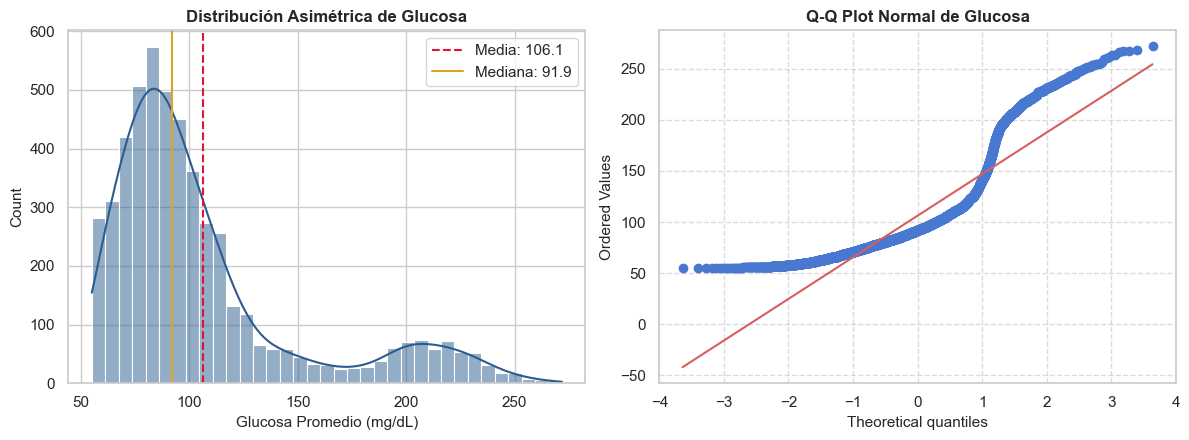

In [38]:
df_plot = pd.read_csv("healthcare_stroke_data.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 1. Histograma con curva de densidad KDE
sns.histplot(df_plot["avg_glucose_level"], kde=True, color="#2b5c8f", bins=35, ax=axes[0])
axes[0].axvline(df_plot["avg_glucose_level"].mean(), color="crimson", linestyle="--", label=f"Media: {df_plot['avg_glucose_level'].mean():.1f}")
axes[0].axvline(df_plot["avg_glucose_level"].median(), color="goldenrod", linestyle="-", label=f"Mediana: {df_plot['avg_glucose_level'].median():.1f}")
axes[0].set_title("Distribución Asimétrica de Glucosa", fontweight="bold")
axes[0].set_xlabel("Glucosa Promedio (mg/dL)")
axes[0].legend()

# 2. Gráfico Q-Q Plot normal
stats.probplot(df_plot["avg_glucose_level"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot Normal de Glucosa", fontweight="bold")
axes[1].grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


## 9. Inciso 8: Estabilización de Varianza y Normalización (Transformación Yeo-Johnson)

Dado que la glucosa presenta una asimetría positiva severa ($Skew \approx 1.57$), muchos modelos estadísticos y algoritmos predictivos (e.g. regresión logística estándar, análisis discriminante lineal) se benefician al estabilizar la varianza mediante la **transformación de potencias de Yeo-Johnson**:
$$\psi(\lambda, y) = \begin{cases} ((y + 1)^\lambda - 1) / \lambda & \text{si } \lambda \neq 0, y \ge 0 \\ \ln(y + 1) & \text{si } \lambda = 0, y \ge 0 \end{cases}$$

SciPy implementa la optimización automática del parámetro $\lambda$ óptimo mediante `scipy.stats.yeojohnson(serie)`.

### Instrucciones:
Implementa la función `transformar_yeo_johnson(serie: pd.Series) -> dict` que reciba la columna numérica y retorne un diccionario con:
- `asimetria_original`: float (redondeado a 3 decimales).
- `asimetria_transformada`: float (redondeado a 3 decimales tras aplicar Yeo-Johnson).
- `lambda_optimo`: float con el parámetro $\lambda$ estimado (redondeado a 3 decimales).
- `valores_transformados`: arreglo de NumPy con los nuevos datos transformados.


In [39]:
def transformar_yeo_johnson(serie: pd.Series) -> dict:
    datos = serie.dropna().values
    
    asimetria_original = stats.skew(datos)
    valores_trans, lambda_opt = stats.yeojohnson(datos)
    asimetria_transformada = stats.skew(valores_trans)
    
    return {
        'asimetria_original': round(asimetria_original, 3),
        'asimetria_transformada': round(asimetria_transformada, 3),
        'lambda_optimo': round(lambda_opt, 3),
        'valores_transformados': valores_trans
    }

try:
    df_raw = pd.read_csv("healthcare_stroke_data.csv")
    res_yj = transformar_yeo_johnson(df_raw["avg_glucose_level"])
    assert isinstance(res_yj, dict), "El resultado debe ser un diccionario"
    assert "asimetria_original" in res_yj and "asimetria_transformada" in res_yj and "lambda_optimo" in res_yj
    assert abs(res_yj["asimetria_original"] - 1.572) < 0.05, "Asimetría original errónea"
    # La asimetría tras Yeo-Johnson debe colapsar a valores muy cercanos a 0 (< 0.15)
    assert abs(res_yj["asimetria_transformada"]) < 0.15, f"La asimetría tras Yeo-Johnson ({res_yj['asimetria_transformada']}) debe ser cercana a 0"
    assert len(res_yj["valores_transformados"]) == len(df_raw), "La longitud del arreglo debe coincidir con los datos"
    print("¡Inciso 8 verificado con éxito! Normalización por Yeo-Johnson exitosa:")
    print(f" - Asimetría Original:     {res_yj['asimetria_original']}")
    print(f" - Asimetría Transformada: {res_yj['asimetria_transformada']} (¡Casi perfectamente simétrica!)")
    print(f" - Parámetro Lambda (lambda): {res_yj['lambda_optimo']}")
except Exception as e:
    print(f"Error en Inciso 8: {type(e).__name__} -> {e}")


¡Inciso 8 verificado con éxito! Normalización por Yeo-Johnson exitosa:
 - Asimetría Original:     1.572
 - Asimetría Transformada: 0.085 (¡Casi perfectamente simétrica!)
 - Parámetro Lambda (lambda): -1.076


## 10. Inciso 9: Análisis de Correlación de Spearman y Asociación con ACV (Stroke)

El coeficiente de correlación de Pearson evalúa exclusivamente dependencias lineales en variables normales. Dado que variables como la glucosa y el IMC presentan asimetría y outliers, y que variables como hipertensión y cardiopatía son binarias discretas, la **correlación por rangos de Spearman ($r_s$)** es la medida no paramétrica idónea para cuantificar relaciones monotónicas.

### Instrucciones:
Implementa la función `analizar_correlacion_stroke(df: pd.DataFrame) -> tuple` que:
1. Seleccione las 6 variables clínicas numéricas: `['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']`.
2. Calcule la matriz de correlación de Spearman usando `.corr(method='spearman')`.
3. Aísle la serie de correlaciones con respecto a `'stroke'`, excluyendo la correlación de `'stroke'` consigo misma.
4. Identifique la variable con la correlación de Spearman más alta con `'stroke'`.
5. Retorne una tupla con tres elementos:
   `(matriz_correlacion: pd.DataFrame, variable_top: str, valor_top: float)` (redondeando el valor a 4 decimales).


In [40]:
def analizar_correlacion_stroke(df: pd.DataFrame) -> tuple:
    columnas = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
    matriz_corr = df[columnas].corr(method='spearman')
    
    corr_stroke = matriz_corr['stroke'].drop('stroke')
    variable_top = corr_stroke.idxmax()
    valor_top = corr_stroke.max()
    
    return matriz_corr, variable_top, float(round(valor_top, 4))

try:
    df_raw = pd.read_csv("healthcare_stroke_data.csv")
    matriz_sp, var_top, val_top = analizar_correlacion_stroke(df_raw)
    assert isinstance(matriz_sp, pd.DataFrame), "El primer elemento debe ser un DataFrame"
    assert var_top == "age", f"La variable con mayor asociación debe ser 'age', pero se obtuvo: {var_top}"
    assert np.isclose(val_top, 0.2495, atol=0.01), f"Correlación esperada ~0.2495, obtenida: {val_top}"
    assert matriz_sp.loc["heart_disease", "stroke"] > matriz_sp.loc["bmi", "stroke"], "Cardiopatía debe tener mayor correlación con stroke que el IMC"
    print(f"¡Inciso 9 verificado con éxito! Variable líder en riesgo: '{var_top}' (rs = {val_top:.4f})")
    print("Ranking de factores de riesgo según correlación de Spearman:")
    print(matriz_sp["stroke"].sort_values(ascending=False).round(4))
except Exception as e:
    print(f"Error en Inciso 9: {type(e).__name__} -> {e}")


¡Inciso 9 verificado con éxito! Variable líder en riesgo: 'age' (rs = 0.2495)
Ranking de factores de riesgo según correlación de Spearman:
stroke               1.0000
age                  0.2495
heart_disease        0.1349
hypertension         0.1279
avg_glucose_level    0.0825
bmi                  0.0554
Name: stroke, dtype: float64


## 11. Inciso 10: Pipeline Integral Reproducible de Preprocesamiento EDA

En producción y ciencia de datos aplicada, todas las etapas de limpieza, imputación y transformación se integran en una **función pipeline modular**.

### Criterio Clínico de Segmentación de Glucosa:
De acuerdo con los estándares de la *American Diabetes Association* (ADA) y la OMS:
- **`'Normal'`**: Glucosa $< 100\text{ mg/dL}$
- **`'Prediabetes'`**: $100\text{ mg/dL} \le \text{Glucosa} \le 125\text{ mg/dL}$
- **`'Diabetes'`**: Glucosa $\ge 126\text{ mg/dL}$

### Instrucciones:
Implementa la función maestra `pipeline_eda_salud(df_input: pd.DataFrame) -> pd.DataFrame` que:
1. Elimine la columna irrelevante `'id'`.
2. Filtre las filas eliminando `gender == 'Other'`.
3. Impute los nulos en `'bmi'` utilizando la **mediana** de dicha columna.
4. Codifique las columnas binarias:
   - `gender`: Male=1, Female=0
   - `ever_married`: Yes=1, No=0
   - `Residence_type`: Urban=1, Rural=0
5. Cree una nueva columna categórica `'categoria_glucosa'` aplicando la segmentación clínica (Normal, Prediabetes, Diabetes).
6. Reinicie los índices del DataFrame resultante con `.reset_index(drop=True)` y lo retorne.


In [41]:
def pipeline_eda_salud(df_input: pd.DataFrame) -> pd.DataFrame:
    df = df_input.copy()
    
    if 'id' in df.columns:
        df = df.drop(columns=['id'])
    
    df = df[df['gender'] != 'Other'].copy()
    
    mediana_bmi = df['bmi'].median()
    df['bmi'] = df['bmi'].fillna(mediana_bmi)
    
    df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
    df['ever_married'] = df['ever_married'].map({'Yes': 1, 'No': 0})
    df['Residence_type'] = df['Residence_type'].map({'Urban': 1, 'Rural': 0})
    
    df['categoria_glucosa'] = pd.cut(
        df['avg_glucose_level'],
        bins=[-np.inf, 100, 125, np.inf],
        labels=['Normal', 'Prediabetes', 'Diabetes'],
        right=False
    )
    
    return df.reset_index(drop=True)
try:
    df_raw = pd.read_csv("healthcare_stroke_data.csv")
    df_final = pipeline_eda_salud(df_raw)
    assert isinstance(df_final, pd.DataFrame), "El resultado debe ser un DataFrame"
    assert "id" not in df_final.columns, "La columna 'id' debió ser eliminada"
    assert len(df_final) == 5109, f"El DataFrame debe tener 5,109 filas, tiene {len(df_final)}"
    assert df_final.isna().sum().sum() == 0, "No debe existir ningún valor nulo en el DataFrame final"
    assert "categoria_glucosa" in df_final.columns, "Falta la columna 'categoria_glucosa'"
    
    conteo_glucosa = df_final["categoria_glucosa"].value_counts().to_dict()
    assert conteo_glucosa["Normal"] == 3131, f"Se esperaban 3,131 pacientes Normales, obtenidos: {conteo_glucosa.get('Normal')}"
    assert conteo_glucosa["Diabetes"] == 999, f"Se esperaban 999 pacientes con Diabetes, obtenidos: {conteo_glucosa.get('Diabetes')}"
    assert conteo_glucosa["Prediabetes"] == 979, f"Se esperaban 979 pacientes con Prediabetes, obtenidos: {conteo_glucosa.get('Prediabetes')}"
    print("¡Inciso 10 (Pipeline Integrador) superado con éxito!")
    print("Dimensiones finales del dataset limpio:", df_final.shape)
    print("Primeras 5 filas del dataset preprocesado:")
    print(df_final.head())
except Exception as e:
    print(f"Error en Inciso 10: {type(e).__name__} -> {e}")


¡Inciso 10 (Pipeline Integrador) superado con éxito!
Dimensiones finales del dataset limpio: (5109, 12)
Primeras 5 filas del dataset preprocesado:
   gender   age  hypertension  heart_disease  ever_married      work_type  \
0       1  67.0             0              1             1        Private   
1       0  61.0             0              0             1  Self-employed   
2       1  80.0             0              1             1        Private   
3       0  49.0             0              0             1        Private   
4       0  79.0             1              0             1  Self-employed   

   Residence_type  avg_glucose_level   bmi   smoking_status  stroke  \
0               1             228.69  36.6  formerly smoked       1   
1               0             202.21  28.1     never smoked       1   
2               0             105.92  32.5     never smoked       1   
3               1             171.23  34.4           smokes       1   
4               0             174.1

## 12. Dashboard Clínico de Cierre: Visualización Multivariada de Riesgo

Para comunicar los hallazgos a la dirección médica y a los epidemiólogos, generamos un **panel visual de 4 cuadrantes (2x2)** con los indicadores clave identificados durante el EDA:
1. **Distribución de Edad por ACV**: Muestra el envejecimiento vascular en pacientes que sufrieron un ACV.
2. **Glucosa e Hipertensión**: Boxplots cruzados que evidencian la sinergia de riesgo metabólico.
3. **Heatmap de Correlaciones Clínicas**: Mapa de calor con coeficientes de Spearman anotados.
4. **Tasa de ACV por Categoría de Glucosa**: Demostración de que la diabetes casi triplica el riesgo de sufrir un evento cerebrovascular.


C:\Users\Angel\AppData\Local\Temp\ipykernel_17332\21777185.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasa_acv = df_p.groupby("categoria_glucosa")["stroke"].mean() * 100


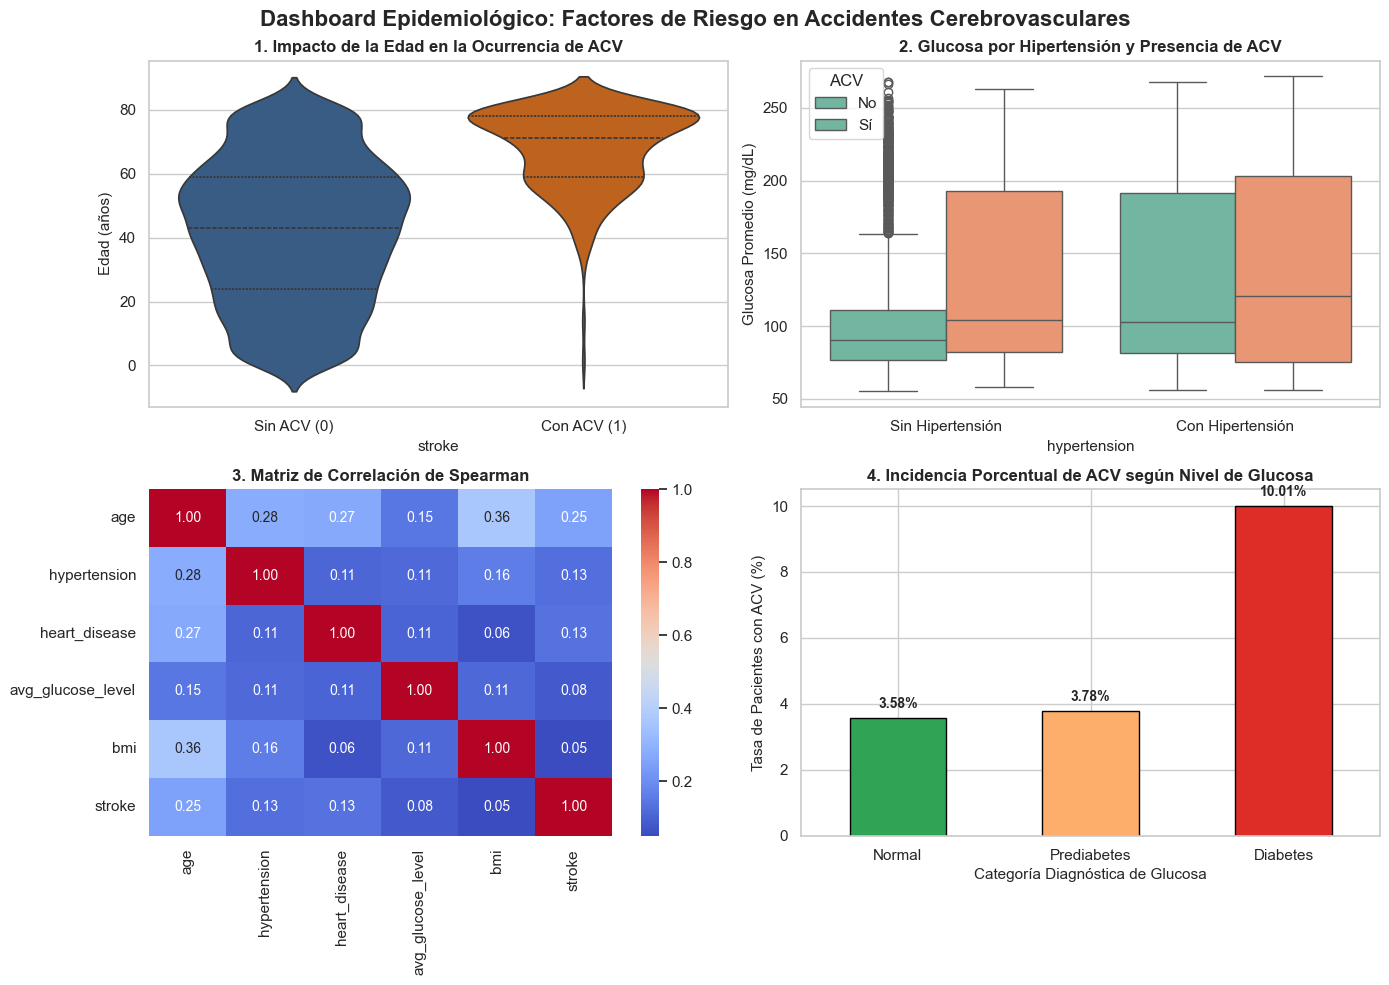

In [42]:
# Generación del Dashboard Clínico Multivariado
df_p = pipeline_eda_salud(pd.read_csv("healthcare_stroke_data.csv"))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Gráfico de Violín: Edad vs ACV
sns.violinplot(data=df_p, x="stroke", y="age", hue="stroke", legend=False, palette=["#2b5c8f", "#d95f02"], inner="quartile", ax=axes[0, 0])
axes[0, 0].set_title("1. Impacto de la Edad en la Ocurrencia de ACV", fontweight="bold")
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(["Sin ACV (0)", "Con ACV (1)"])
axes[0, 0].set_ylabel("Edad (años)")

# 2. Boxplot: Glucosa vs Hipertensión desglosado por ACV
sns.boxplot(data=df_p, x="hypertension", y="avg_glucose_level", hue="stroke", palette="Set2", ax=axes[0, 1])
axes[0, 1].set_title("2. Glucosa por Hipertensión y Presencia de ACV", fontweight="bold")
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(["Sin Hipertensión", "Con Hipertensión"])
axes[0, 1].set_ylabel("Glucosa Promedio (mg/dL)")
axes[0, 1].legend(title="ACV", labels=["No", "Sí"])

# 3. Heatmap de Correlación de Spearman
cols_corr = ["age", "hypertension", "heart_disease", "avg_glucose_level", "bmi", "stroke"]
matriz_corr = df_p[cols_corr].corr(method="spearman")
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, ax=axes[1, 0])
axes[1, 0].set_title("3. Matriz de Correlación de Spearman", fontweight="bold")

# 4. Tasa de Incidencia de ACV por Categoría de Glucosa
tasa_acv = df_p.groupby("categoria_glucosa")["stroke"].mean() * 100
orden_cat = ["Normal", "Prediabetes", "Diabetes"]
tasa_acv = tasa_acv.reindex(orden_cat)

tasa_acv.plot(kind="bar", color=["#31a354", "#fdae6b", "#de2d26"], edgecolor="black", ax=axes[1, 1])
axes[1, 1].set_title("4. Incidencia Porcentual de ACV según Nivel de Glucosa", fontweight="bold")
axes[1, 1].set_ylabel("Tasa de Pacientes con ACV (%)")
axes[1, 1].set_xlabel("Categoría Diagnóstica de Glucosa")
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.3), ha="center", fontsize=10, fontweight="bold")
plt.xticks(rotation=0)

plt.suptitle("Dashboard Epidemiológico: Factores de Riesgo en Accidentes Cerebrovasculares", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()
